# Video Highlight Detection — на датасете TVSum

Промежуточный отчёт Stage 1 по проекту «Поиск хайлайтов в видео».

- **Датасет**: TVSum50 (50 видео, 20 аннотаторов, shot-level importance).
- **Тип задачи**: temporal highlight detection через предсказание важности по времени.
- **Вход**: последовательность визуальных признаков `x_t` (GoogLeNet pool5, 1024-D, ~2 fps).
- **Таргет**: `gtscore_t` (непрерывная важность), вспомогательная проверка через `user_summary`.
- **Выход модели**: `score_t` + постобработка в бинарное summary по разметке (`user_summary`/`gtsummary`) с ограничением длины 15% и knapsack.

**Источники:**  
- [TVSum (Song et al., CVPR 2015)](https://github.com/yalesong/tvsum)  
- [Пакет pre-extracted features (ECCV'16)](https://drive.google.com/open?id=1Bf0beMN_ieiM3JpprghaoOwQe9QJIyAN)


## 0. Что мы решаем, требования и ограничения

### Как устроена задача
Есть видео, после извлечения признаков оно выглядит как последовательность $X = \{x_t\}_{t=1}^{T}$, где $x_t \in \mathbb{R}^{1024}$.
Модель предсказывает $\hat{y}_t \in [0,1]$ — насколько момент времени $t$ важный.

Дальше из $\hat{y}$ получаем итоговое summary и сравниваем его с разметкой `user_summary`/`gtsummary`:
1. переносим score с шагов на кадры;
2. усредняем score внутри shot-сегментов (`change_points`);
3. выбираем сегменты через 0/1 knapsack так, чтобы длина summary была $\leq 15\%$ от видео.

### Что важно для проекта
- **Качество**: итоговое summary должно быть похоже на разметку пользователей.
- **Масштабируемость**: решение должно подходить для пакетной обработки большого числа видео.
- **Ресурсы**: приемлемые время инференса и размер модели.

### Ограничения
- Разметка субъективна: 20 пользователей могут выбирать разные хайлайты.
- Длина видео сильно различается (`n_steps` меняется в широком диапазоне).
- Есть разные жанры видео, возможен доменный сдвиг.
- На этом этапе используем только визуальные признаки (без аудио/ASR).

### Что считаем успешным на Stage 1
- Рабочий и воспроизводимый расчёт метрик (Spearman + F1@15%).
- Получены воспроизводимые числа по всем методам, без завышенных выводов о победителе на таком объёме данных.


In [1]:
!pip install h5py scipy torch numpy matplotlib seaborn tqdm scikit-learn gdown -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, json, math, random
from pathlib import Path
from collections import defaultdict

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    'cuda'  if torch.cuda.is_available()  else
    'mps'   if torch.backends.mps.is_available() else
    'cpu'
)
print(f"{DEVICE = }")

/Users/b.karamov/Desktop/edu/CV/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = device(type='mps')


## 1. Загрузка датасета

Архив содержит `eccv16_dataset_tvsum_google_pool5.h5` (~170 MB) — предобработанный датасет с GoogLeNet-фичами.  

### Структура h5-файла
```
/video_1/
    features        — (n_steps, 1024)   фичи подвыборки кадров (≈2 fps)
    gtscore         — (n_steps,)        нормализованные оценки важности [0..1]
    user_summary    — (20, n_frames)    бинарные саммари 20 аннотаторов
    change_points   — (n_segs, 2)       границы сегментов (shot detection)
    n_frame_per_seg — (n_segs,)         кол-во кадров в каждом сегменте
    n_frames        — scalar            всего кадров в оригинальном видео
    picks           — (n_steps,)        индексы подвыборочных кадров
    n_steps         — scalar            кол-во подвыборочных кадров
```

### Данные: источники, лицензии, структура, объём

| Поле | Значение |
|---|---|
| Источник датасета | TVSum50 (YouTube-видео, аннотации пользователей) |
| Лицензия/доступ | Открытый исследовательский датасет (нужно указывать источник и paper) |
| Файл в эксперименте | `eccv16_dataset_tvsum_google_pool5.h5` |
| Количество видео | 50 |
| Объём признаков | `1024-D` на шаг, шаг дискретизации около `2 fps` |
| Суммарная длительность (оценка) | `~3.27 часа` (по `n_steps/2`) |
| Суммарный объём кадров | `352,353` кадра |

### Разметка / таргет
- `gtscore (T,)` — непрерывная оценка важности, используется как таргет для обучения (регрессия/ранжирование).
- `user_summary (20, n_frames)` — 20 бинарных пользовательских summary (`user_summary`), используется для итоговой F1-оценки.
- `change_points + n_frame_per_seg` — shot-структура для сегментного выбора при knapsack-постобработке.

### Признаки / представления
- Используются **готовые визуальные признаки** `GoogLeNet pool5`.
- Почему: это быстрый baseline-представление для Stage 1, позволяющее фокусироваться на сравнении temporal-моделей.
- Ограничение: признаки старого поколения, без языковой/семантической мультимодальности (например, CLIP + text).


In [3]:
H5_PATH = 'datasets/eccv16_dataset_tvsum_google_pool5.h5'

print(f"Файл: {H5_PATH}")
print(f"Размер: {os.path.getsize(H5_PATH) / 1e6:.1f} MB")

Файл: datasets/eccv16_dataset_tvsum_google_pool5.h5
Размер: 125.1 MB


## 2. Исследование датасета (EDA)

In [4]:
# Загружаем h5 и смотрим структуру
with h5py.File(H5_PATH, 'r') as f:
    video_keys = list(f.keys())
    print(f"Всего видео: {len(video_keys)}")
    print(f"    Ключи: {video_keys[:5]} ... {video_keys[-2:]}")

    print("\nПоля одного видео")
    key = video_keys[0]
    for field in f[key].keys():
        v = f[key][field]
        if hasattr(v, 'shape'):
            print(f"   {field:20s}  shape={v.shape}  dtype={v.dtype}")
        else:
            print(f"   {field:20s}  value={v[()]}")

print(f"\nДатасет загружен")

Всего видео: 50
    Ключи: ['video_1', 'video_10', 'video_11', 'video_12', 'video_13'] ... ['video_8', 'video_9']

Поля одного видео
   change_points         shape=(71, 2)  dtype=int64
   features              shape=(707, 1024)  dtype=float32
   gtscore               shape=(707,)  dtype=float32
   gtsummary             shape=(707,)  dtype=float32
   n_frame_per_seg       shape=(71,)  dtype=int64
   n_frames              shape=()  dtype=int64
   n_steps               shape=()  dtype=int64
   picks                 shape=(707,)  dtype=int64
   user_summary          shape=(20, 10597)  dtype=float32

Датасет загружен


In [5]:
# Загружаем все видео в словарь
dataset = {}
with h5py.File(H5_PATH, 'r') as f:
    for key in f.keys():
        dataset[key] = {
            'features': f[key]['features'][:],                # (T, 1024)
            'gtscore': f[key]['gtscore'][:],                  # (T,)
            'user_summary': f[key]['user_summary'][:],        # (20, n_frames)
            'change_points': f[key]['change_points'][:],      # (n_segs, 2)
            'n_frame_per_seg': f[key]['n_frame_per_seg'][:],  # (n_segs,)
            'n_frames': int(f[key]['n_frames'][()]),
            'picks': f[key]['picks'][:],                      # (T,)
            'n_steps': int(f[key]['n_steps'][()]),
        }

video_keys = list(dataset.keys())
print(f"Загружено {len(dataset)} видео")

# Статистика
n_steps_list = [dataset[k]['n_steps'] for k in video_keys]
n_frames_list = [dataset[k]['n_frames'] for k in video_keys]
n_segs_list = [dataset[k]['change_points'].shape[0] for k in video_keys]

print(f"\nСтатистика")
print(f"   n_steps  (подвыборочных кадров): min={min(n_steps_list)}, max={max(n_steps_list)}, mean={np.mean(n_steps_list):.0f}")
print(f"   n_frames (оригинальных кадров):  min={min(n_frames_list)}, max={max(n_frames_list)}, mean={np.mean(n_frames_list):.0f}")
print(f"   n_segs   (сегментов):            min={min(n_segs_list)}, max={max(n_segs_list)}, mean={np.mean(n_segs_list):.1f}")

Загружено 50 видео

Статистика
   n_steps  (подвыборочных кадров): min=167, max=1294, mean=470
   n_frames (оригинальных кадров):  min=2500, max=19406, mean=7047
   n_segs   (сегментов):            min=17, max=130, mean=47.5


In [6]:
# Проверка качества данных (валидность и целостность)
def run_data_quality_checks(data_dict):
    report = {
        'videos_total': len(data_dict),
        'non_monotonic_picks': 0,
        'out_of_range_picks': 0,
        'bad_change_points': 0,
        'cp_seg_len_mismatch': 0,
        'empty_user_summary': 0,
        'length_mismatch_feat_target': 0,
        'nan_in_features': 0,
        'nan_in_gtscore': 0,
    }

    for d in data_dict.values():
        picks = d['picks']
        cps = d['change_points']
        nfps = d['n_frame_per_seg']
        n_frames = d['n_frames']

        if np.any(np.diff(picks) < 0):
            report['non_monotonic_picks'] += 1
        if len(picks) == 0 or picks.min() < 0 or picks.max() >= n_frames:
            report['out_of_range_picks'] += 1

        if np.any(cps[:, 0] > cps[:, 1]) or np.any(cps < 0) or np.any(cps[:, 1] >= n_frames):
            report['bad_change_points'] += 1

        seg_len_from_cps = cps[:, 1] - cps[:, 0] + 1
        if len(seg_len_from_cps) != len(nfps) or np.mean(np.abs(seg_len_from_cps - nfps)) > 5:
            report['cp_seg_len_mismatch'] += 1

        if d['user_summary'].sum() == 0:
            report['empty_user_summary'] += 1

        if d['features'].shape[0] != len(d['gtscore']) or d['features'].shape[0] != d['n_steps']:
            report['length_mismatch_feat_target'] += 1

        if np.isnan(d['features']).any():
            report['nan_in_features'] += 1
        if np.isnan(d['gtscore']).any():
            report['nan_in_gtscore'] += 1

    return report


dq = run_data_quality_checks(dataset)
steps_total = sum(dataset[k]['n_steps'] for k in dataset)
frames_total = sum(dataset[k]['n_frames'] for k in dataset)
est_hours_2fps = steps_total / 2 / 3600

print('Data quality checks')
for k, v in dq.items():
    print(f'  {k:<28}: {v}')
print(f'\nСуммарные n_steps: {steps_total}')
print(f'Суммарные кадры:   {frames_total}')
print(f'Оценка длительности (~2 fps): {est_hours_2fps:.2f} часа')

Data quality checks
  videos_total                : 50
  non_monotonic_picks         : 0
  out_of_range_picks          : 0
  bad_change_points           : 0
  cp_seg_len_mismatch         : 0
  empty_user_summary          : 0
  length_mismatch_feat_target : 0
  nan_in_features             : 0
  nan_in_gtscore              : 0

Суммарные n_steps: 23510
Суммарные кадры:   352353
Оценка длительности (~2 fps): 3.27 часа


### Расшифровка проверок качества данных

- `non_monotonic_picks` — проверка, что индексы подвыборки кадров (`picks`) идут по времени и не "прыгают назад".
- `out_of_range_picks` — проверка, что все `picks` лежат в пределах `[0, n_frames)`.
- `bad_change_points` — проверка корректности границ сегментов: начало <= конец, индексы не отрицательные и не выходят за видео.
- `cp_seg_len_mismatch` — проверка согласованности `change_points` и `n_frame_per_seg` (длины сегментов должны совпадать).
- `empty_user_summary` — проверка, что в разметке пользователя есть отмеченные кадры, а не полностью пустой вектор.
- `length_mismatch_feat_target` — проверка, что длины `features`, `gtscore` и `n_steps` совпадают.
- `nan_in_features` — проверка отсутствия NaN в признаках.
- `nan_in_gtscore` — проверка отсутствия NaN в целевой переменной `gtscore`.

В текущем запуске по всем этим пунктам получено 0, то есть базовая структура и целостность данных в порядке.


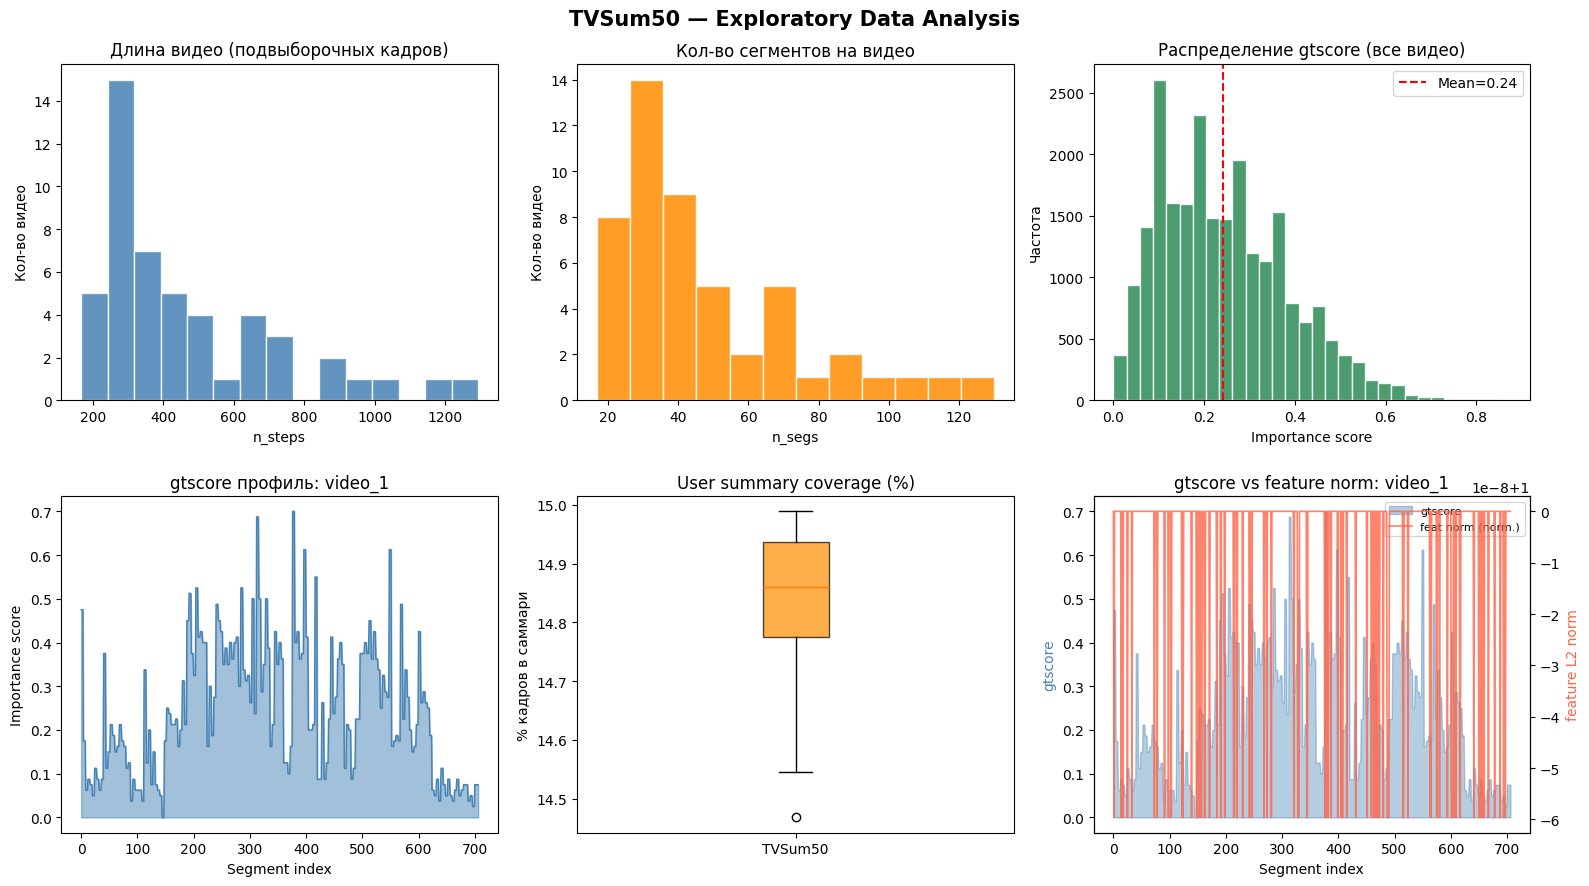

In [ ]:
# Визуализация EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('TVSum50 — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# 1. Распределение длин видео (n_steps)
axes[0,0].hist(n_steps_list, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Длина видео (подвыборочных кадров)')
axes[0,0].set_xlabel('n_steps'); axes[0,0].set_ylabel('Кол-во видео')

# 2. Распределение числа сегментов
axes[0,1].hist(n_segs_list, bins=12, color='darkorange', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Кол-во сегментов на видео')
axes[0,1].set_xlabel('n_segs'); axes[0,1].set_ylabel('Кол-во видео')

# 3. Распределение gt-scores (всех видео)
all_gts = np.concatenate([dataset[k]['gtscore'] for k in video_keys])
axes[0,2].hist(all_gts, bins=30, color='seagreen', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Распределение gtscore (все видео)')
axes[0,2].set_xlabel('Importance score'); axes[0,2].set_ylabel('Частота')
axes[0,2].axvline(all_gts.mean(), color='red', linestyle='--', label=f'Mean={all_gts.mean():.2f}')
axes[0,2].legend()

# 4. gt-score профиль одного видео
key_ex = video_keys[0]
gts_ex = dataset[key_ex]['gtscore']
axes[1,0].fill_between(range(len(gts_ex)), gts_ex, alpha=0.5, color='steelblue')
axes[1,0].plot(gts_ex, color='steelblue', linewidth=1)
axes[1,0].set_title(f'gtscore профиль: {key_ex}')
axes[1,0].set_xlabel('Segment index'); axes[1,0].set_ylabel('Importance score')

# 5. User summary coverage (%)
coverage = []
for k in video_keys:
    us = dataset[k]['user_summary']  # (20, n_frames)
    coverage.append(us.mean(axis=1).mean() * 100)
axes[1,1].boxplot(coverage, patch_artist=True, boxprops=dict(facecolor='darkorange', alpha=0.7))
axes[1,1].set_title('User summary coverage (%)')
axes[1,1].set_ylabel('% кадров в саммари')
axes[1,1].set_xticks([1]); axes[1,1].set_xticklabels(['TVSum50'])

# 6. L2-норма фич (прокси-метрика визуальной интенсивности)
norms_ex = np.linalg.norm(dataset[key_ex]['features'], axis=1)
ax2 = axes[1,2].twinx()
axes[1,2].fill_between(range(len(gts_ex)), gts_ex, alpha=0.4, color='steelblue', label='gtscore')
ax2.plot(norms_ex / norms_ex.max(), color='tomato', linewidth=1.2, alpha=0.8, label='feat norm (norm.)')
axes[1,2].set_title(f'gtscore vs feature norm: {key_ex}')
axes[1,2].set_xlabel('Segment index')
axes[1,2].set_ylabel('gtscore', color='steelblue')
ax2.set_ylabel('feature L2 norm', color='tomato')
lines1, labels1 = axes[1,2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1,2].legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)


plt.tight_layout()
plt.savefig('images/eda_tvsum.png', dpi=130, bbox_inches='tight')
plt.show()
print("Графики сохранены: eda_tvsum.png")

### Что показывают EDA-графики

1. **Длина видео (`n_steps`)**  
После подвыборки (~2 fps) длины сильно отличаются. Значит модель должна нормально работать и на коротких, и на длинных видео.

2. **Число сегментов (`n_segs`)**  
У одних видео мало сегментов, у других много. Это напрямую влияет на то, насколько сложно собрать итоговое summary.

3. **Распределение `gtscore`**  
Среднее около 0.24, то есть по времени чаще встречаются низкие и средние оценки, а высокие — реже.

4. **Профиль `gtscore` для `video_1`**  
Есть отдельные пики важности и длинные спокойные участки. Значит важно точно находить именно пики.

5. **`User summary coverage (%)`**  
Доля кадров в пользовательской разметке `user_summary` держится около 15%. Это согласуется с ограничением длины summary в 15%.

6. **`gtscore` vs `feature norm`**  
По визуализации явной устойчивой связи не видно, поэтому этот baseline нельзя считать надёжным ориентиром качества.

### Короткий вывод по EDA

- Данные неоднородные по длине и сегментации.
- Важные моменты встречаются реже, чем фоновые.
- Ограничение длины 15% хорошо соответствует разметке `user_summary`.

## 3. Класс датасета и схема 5-fold CV

Используем стандартную для TVSum схему: делим 50 видео на 5 фолдов по 10 видео,
обучаемся на 40 и проверяемся на 10, затем усредняем метрики по всем 50 тестовым видео.

Метрики:
- **Spearman ρ** — корреляция рангов между предсказанными score и `gtscore` (на уровне `n_steps`).
- **F1-score** — сравнение машинного summary с разметкой `user_summary` через 0/1 knapsack (на уровне `n_frames`).


In [8]:
import torch
from torch.utils.data import Dataset

class TVSumDataset(Dataset):
    """Один элемент = одно видео. Возвращаем features, gtscore и key."""
    def __init__(self, keys, data_dict):
        self.keys = keys
        self.data = data_dict

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        k = self.keys[idx]
        d = self.data[k]
        feats  = torch.tensor(d['features'], dtype=torch.float32)  # (T, 1024)
        scores = torch.tensor(d['gtscore'],  dtype=torch.float32)  # (T,)
        return feats, scores, k

def collate_fn(batch):
    """Batch size всегда 1, просто добавляем ось батча."""
    feats, scores, key = batch[0]
    return feats.unsqueeze(0), scores.unsqueeze(0), key  # (1,T,1024), (1,T)

keys_shuffled = video_keys.copy()
random.shuffle(keys_shuffled)

N_FOLDS = 5
fold_size = len(keys_shuffled) // N_FOLDS
folds = [keys_shuffled[i*fold_size:(i+1)*fold_size] for i in range(N_FOLDS)]

splits = []
for i in range(N_FOLDS):
    test_keys  = folds[i]
    train_keys = [k for j, fold in enumerate(folds) for k in fold if j != i]
    splits.append({'train': train_keys, 'test': test_keys})

print(f"5-fold CV сплиты созданы")
for i, s in enumerate(splits):
    print(f"   Fold {i}: train={len(s['train'])} видео, test={len(s['test'])} видео")

5-fold CV сплиты созданы
   Fold 0: train=40 видео, test=10 видео
   Fold 1: train=40 видео, test=10 видео
   Fold 2: train=40 видео, test=10 видео
   Fold 3: train=40 видео, test=10 видео
   Fold 4: train=40 видео, test=10 видео


## 4. Метрики и как мы их считаем

### Почему эти метрики
- **Spearman ρ**: показывает, насколько правильно модель ранжирует моменты по важности.
- **F1@15%**: показывает качество итогового summary относительно разметки `user_summary`.

### Как считаем метрики
1. Для каждого видео получаем `pred_scores` на уровне `n_steps`.
2. Считаем `Spearman(pred_scores, gtscore)`.
3. Строим бинарное summary через knapsack с ограничением длины `15%`.
4. Считаем `precision/recall/F1` относительно каждого из 20 пользователей в `user_summary`.
5. Для одного видео берём среднее по пользователям (`eval_metric='avg'`).
6. Для фолда берём среднее по видео тестовой части.
7. Финально берём среднее по всем видео из всех 5 фолдов.


In [9]:
def knapsack_dp(values, weights, n_items, capacity):
    """0/1 knapsack: выбираем сегменты с макс. score при ограничении по длине."""
    table = np.zeros((n_items + 1, capacity + 1), dtype=np.float32)
    keep  = np.zeros((n_items + 1, capacity + 1), dtype=np.int8)

    for i in range(1, n_items + 1):
        wi = int(weights[i-1])
        vi = float(values[i-1])
        for w in range(capacity + 1):
            if wi <= w and vi + table[i-1][w-wi] > table[i-1][w]:
                table[i][w] = vi + table[i-1][w-wi]
                keep[i][w]  = 1
            else:
                table[i][w] = table[i-1][w]

    picks, w = [], capacity
    for i in range(n_items, 0, -1):
        if keep[i][w] == 1:
            picks.append(i-1)
            w -= int(weights[i-1])
    return picks


def generate_summary(ypred, cps, n_frames, nfps, positions, proportion=0.15):
    """Из score по шагам строит бинарный summary по кадрам."""
    n_segs = cps.shape[0]

    # 1. Map scores from subsampled → all frames
    frame_scores = np.zeros(n_frames, dtype=np.float32)
    pos = positions.astype(np.int32)
    if pos[-1] != n_frames:
        pos = np.concatenate([pos, [n_frames]])
    for i in range(len(pos) - 1):
        frame_scores[pos[i]:pos[i+1]] = ypred[i]

    # 2. Average score per segment
    seg_scores = []
    for seg_idx in range(n_segs):
        s, e = int(cps[seg_idx, 0]), int(cps[seg_idx, 1] + 1)
        seg_scores.append(float(frame_scores[s:e].mean()))

    # 3. Knapsack selection
    capacity = int(math.floor(n_frames * proportion))
    selected = knapsack_dp(seg_scores, nfps.tolist(), n_segs, capacity)

    # 4. Build binary vector
    parts = []
    for seg_idx in range(n_segs):
        nf = int(nfps[seg_idx])
        parts.append(np.ones(nf, dtype=np.float32) if seg_idx in selected
                     else np.zeros(nf, dtype=np.float32))
    return np.concatenate(parts)


def evaluate_f1(machine_summary, user_summary, eval_metric='avg'):
    """Считает F1/precision/recall между машинным summary и user_summary."""
    ms = machine_summary.astype(np.float32)
    us = user_summary.astype(np.float32)
    n_users, n_frames = us.shape

    ms[ms > 0] = 1.0; us[us > 0] = 1.0
    if len(ms) > n_frames:   ms = ms[:n_frames]
    elif len(ms) < n_frames: ms = np.concatenate([ms, np.zeros(n_frames - len(ms))])

    f_scores, prec_arr, rec_arr = [], [], []
    for u in range(n_users):
        overlap = (ms * us[u]).sum()
        p = overlap / (ms.sum() + 1e-8)
        r = overlap / (us[u].sum() + 1e-8)
        f = 2 * p * r / (p + r + 1e-8)
        f_scores.append(f); prec_arr.append(p); rec_arr.append(r)

    if eval_metric == 'avg':
        return np.mean(f_scores), np.mean(prec_arr), np.mean(rec_arr)
    else:  # max
        idx = int(np.argmax(f_scores))
        return f_scores[idx], prec_arr[idx], rec_arr[idx]


def evaluate_spearman(pred_scores, gt_scores):
    """Spearman между pred и gt. Для константного сигнала возвращаем nan."""
    pred_std = float(np.std(pred_scores))
    gt_std = float(np.std(gt_scores))
    if pred_std < 1e-12 or gt_std < 1e-12:
        return float('nan')
    corr, _ = spearmanr(pred_scores, gt_scores)
    return float(corr)


def safe_nanmean(values):
    arr = np.asarray(values, dtype=np.float64)
    return float(np.nanmean(arr)) if np.isfinite(arr).any() else float('nan')


def evaluate_video(key, pred_scores_np):
    """Считает все метрики для одного видео."""
    d = dataset[key]
    spear = evaluate_spearman(pred_scores_np, d['gtscore'])
    summary = generate_summary(pred_scores_np,
                                d['change_points'], d['n_frames'],
                                d['n_frame_per_seg'], d['picks'])
    f1, prec, rec = evaluate_f1(summary, d['user_summary'])
    return {'spearman': spear, 'f1': f1 * 100, 'precision': prec * 100, 'recall': rec * 100}

print("Функции для оценки загружены")
print(f"   knapsack_dp, generate_summary, evaluate_f1, evaluate_spearman, evaluate_video")

Функции для оценки загружены
   knapsack_dp, generate_summary, evaluate_f1, evaluate_spearman, evaluate_video


## 5. Базовые решения (Baselines)

Три простых baseline, которые не требуют обучения:

| Baseline | Описание |
|---|---|
| **Random** | Случайные scores ~ Uniform(0, 1) |
| **Feature Norm** | L2-норма фичей как proxy «визуальной активности» |
| **Constant** | Одинаковый score для всех сегментов (константный предиктор) |

Эти baseline важны для:
- Установки нижней границы метрик
- Проверки корректности пайплайна оценки
- Обнаружения bias в датасете

In [10]:
def aggregate_metric_dict(results):
    out = {}
    for metric in results[0].keys():
        vals = [r[metric] for r in results]
        out[metric] = safe_nanmean(vals)
    return out


def run_baseline(baseline_fn, keys):
    """Гоняем baseline по списку видео и усредняем метрики."""
    results = []
    for k in keys:
        feats = dataset[k]['features']  # (T, 1024)
        pred = baseline_fn(feats)       # -> (T,)
        results.append(evaluate_video(k, pred))

    agg = aggregate_metric_dict(results)
    agg['spearman_nan_videos'] = int(sum(not np.isfinite(r['spearman']) for r in results))
    return agg


def baseline_random(features):
    return np.random.rand(len(features)).astype(np.float32)


def baseline_feat_norm(features):
    norms = np.linalg.norm(features, axis=1)
    return (norms / (norms.max() + 1e-8)).astype(np.float32)


def baseline_constant(features):
    return np.full(len(features), 0.5, dtype=np.float32)


print('Оцениваем baselines на всех 50 видео...')
np.random.seed(SEED)

baselines = {
    'Random': run_baseline(baseline_random, video_keys),
    'Feature Norm': run_baseline(baseline_feat_norm, video_keys),
    'Constant (0.5)': run_baseline(baseline_constant, video_keys),
}

print('\nРезультаты Baselines')
print(f"{'Метод':<20} {'Spearman ρ':>12} {'F1 (%)':>10} {'Prec (%)':>10} {'Rec (%)':>10} {'nan ρ':>8}")
print('-' * 76)
for name, m in baselines.items():
    print(f"{name:<20} {m['spearman']:>12.4f} {m['f1']:>10.2f} {m['precision']:>10.2f} {m['recall']:>10.2f} {m['spearman_nan_videos']:>8}")

Оцениваем baselines на всех 50 видео...

Результаты Baselines
Метод                  Spearman ρ     F1 (%)   Prec (%)    Rec (%)    nan ρ
----------------------------------------------------------------------------
Random                     0.0088      54.69      54.60      54.78        0
Feature Norm               0.0077      56.58      56.51      56.67        0
Constant (0.5)                nan      56.58      56.51      56.67       50


## 6. Архитектуры нейронных сетей

Три модели, каждая принимает на вход **всё видео целиком** (batch=1, seq_len=T, feat_dim=1024):

### MLP (независимая обработка сегментов)
- Каждый сегмент обрабатывается независимо: Linear → ReLU → Dropout → Linear → score
- Не учитывает временной контекст, быстрый baseline

### BiLSTM (последовательное моделирование)
- Input projection: 1024 → 256
- BiLSTM (bidirectional): учитывает прошлый и будущий контекст
- Score head: 512 → 64 → 1
- **Идея**: «важный» момент может зависеть от того, что было до и после него

### Transformer Encoder (self-attention)
- Input projection: 1024 → 256 + positional encoding
- Multi-head self-attention (4 heads, 2 слоя): каждый сегмент «видит» все другие сегменты
- Score head: 256 → 64 → 1
- **Идея**: моделируем глобальные зависимости (начало видео важно для понимания финала)

### Loss функция
`MSELoss(predicted_scores, gtscore)` + опционально **pairwise ranking loss**:
если gtscore[i] > gtscore[j] + margin, то штрафуем если pred[i] < pred[j]

In [11]:
import torch
import torch.nn as nn
import math

class MLP(nn.Module):
    """Простой MLP без учета контекста по времени."""
    def __init__(self, feat_dim=1024, hidden=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 64),       nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
    def forward(self, x):  # x: (1, T, 1024)
        return self.net(x).squeeze(-1)  # (1, T)


class BiLSTM(nn.Module):
    """BiLSTM: учитывает контекст до и после момента."""
    def __init__(self, feat_dim=1024, hidden=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(feat_dim, hidden)
        # LSTM всегда на CPU из-за бага MPS с bidirectional
        self.lstm = nn.LSTM(hidden, hidden, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self._lstm_on_cpu = True  # флаг
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(nn.Linear(hidden*2, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x):              # x: (1, T, 1024)
        x = self.proj(x)               # (1, T, 256)
        if self._lstm_on_cpu:
            x_cpu = x.cpu()
            h, _ = self.lstm(x_cpu)    # LSTM на CPU
            h = h.to(x.device)         # возвращаем обратно на MPS
        else:
            h, _ = self.lstm(x)
        return self.head(self.drop(h)).squeeze(-1)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)
    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class TransformerHighlight(nn.Module):
    """Transformer encoder с self-attention по всей последовательности."""
    def __init__(self, feat_dim=1024, d_model=256, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(feat_dim, d_model)
        self.pe   = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):  # x: (1, T, 1024)
        x = self.pe(self.proj(x))    # (1, T, 256)
        h = self.transformer(x)      # (1, T, 256)
        return self.head(h).squeeze(-1)  # (1, T)


def ranking_loss(pred, gt, margin=0.5):
    """Ranking loss: штраф, если модель путает порядок важных моментов."""
    diff_gt   = gt.unsqueeze(1) - gt.unsqueeze(0)       # (T, T)
    diff_pred = pred.unsqueeze(1) - pred.unsqueeze(0)    # (T, T)
    mask = (diff_gt > margin).float()
    loss = mask * torch.clamp(margin - diff_pred, min=0)
    return loss.sum() / (mask.sum() + 1e-8)


for name, Model in [('MLP', MLP), ('BiLSTM', BiLSTM), ('Transformer', TransformerHighlight)]:
    m = Model()
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"   {name:<20}: {n:>8,} параметров")

   MLP                 :  278,913 параметров
   BiLSTM              : 2,924,929 параметров
   Transformer         : 1,858,433 параметров


## 7. Обучение и 5-fold CV

### Параметры обучения
- **Batch size = 1**: одно видео в батче (длины последовательностей разные).
- **Оптимизатор**: Adam, `lr=1e-4`, `weight_decay=1e-5`.
- **Loss**: `MSE + λ * Ranking Loss` (`λ=0.1`).
- **Эпохи**: 50.
- **Gradient clipping**: `max_norm=5.0`.

### Как считаем итог
Для каждого фолда: обучение на 40 видео, оценка на 10.
Итоговая метрика: среднее по всем 50 тестовым видео.


In [12]:
def train_one_epoch(model, train_keys, optimizer, lambda_rank=0.1):
    model.train()
    total_loss = 0.0
    keys_shuffled = train_keys.copy()
    random.shuffle(keys_shuffled)

    for key in keys_shuffled:
        d = dataset[key]
        feats  = torch.tensor(d['features'], dtype=torch.float32).unsqueeze(0).to(DEVICE)  # (1,T,1024)
        scores = torch.tensor(d['gtscore'],  dtype=torch.float32).unsqueeze(0).to(DEVICE)  # (1,T)

        pred = model(feats)  # (1, T)

        mse_loss  = nn.functional.mse_loss(pred, scores)
        rank_loss = ranking_loss(pred.squeeze(0), scores.squeeze(0))
        loss = mse_loss + lambda_rank * rank_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(train_keys)


@torch.no_grad()
def eval_model(model, test_keys):
    model.eval()
    results = []
    for key in test_keys:
        d = dataset[key]
        feats = torch.tensor(d['features'], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        pred  = model(feats).squeeze(0).cpu().numpy()  # (T,)
        results.append(evaluate_video(key, pred))
    out = {metric: safe_nanmean([r[metric] for r in results]) for metric in results[0]}
    out['spearman_nan_videos'] = int(sum(not np.isfinite(r['spearman']) for r in results))
    return out


def run_cv(model_class, model_kwargs, n_epochs=50, lr=1e-4, wd=1e-5, verbose=True):
    """Запуск 5-fold CV для одной модели. На выходе средние метрики и история по фолдам."""
    all_test_results = []  # метрики по каждому тестовому видео
    fold_history = []

    for fold_idx, split in enumerate(splits):
        if verbose:
            print(f"  Fold {fold_idx+1}/5 ...", end=' ')

        model = model_class(**model_kwargs).to(DEVICE)
        # BiLSTM: LSTM должен оставаться на CPU из-за бага MPS
        if hasattr(model, 'lstm'):
            model.lstm = model.lstm.cpu()
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

        train_loss_curve = []
        for epoch in range(n_epochs):
            loss = train_one_epoch(model, split['train'], optimizer)
            train_loss_curve.append(loss)

        # Оцениваем на тесте — по каждому видео отдельно
        model.eval()
        for key in split['test']:
            d = dataset[key]
            feats = torch.tensor(d['features'], dtype=torch.float32).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                pred = model(feats).squeeze(0).cpu().numpy()
            all_test_results.append(evaluate_video(key, pred))

        fold_mean = eval_model(model, split['test'])
        fold_history.append(fold_mean)
        if verbose:
            print(f"Spearman={fold_mean['spearman']:.4f}  F1={fold_mean['f1']:.2f}%")

    # Итоговые метрики по всем 50 тестовым видео
    final = {metric: safe_nanmean([r[metric] for r in all_test_results]) for metric in all_test_results[0]}
    final['spearman_nan_videos'] = int(sum(not np.isfinite(r['spearman']) for r in all_test_results))
    return final, fold_history

print("Функции обучения и оценки готовы")
print("   train_one_epoch, eval_model, run_cv")

Функции обучения и оценки готовы
   train_one_epoch, eval_model, run_cv


In [13]:
results_cv = {}

print("=" * 60)
print("MLP")
print("=" * 60)
res_mlp, hist_mlp = run_cv(
    MLP, {'feat_dim': 1024, 'hidden': 256, 'dropout': 0.3},
    n_epochs=50
)
results_cv['MLP'] = res_mlp

print("\n" + "=" * 60)
print("BiLSTM")
print("=" * 60)
res_lstm, hist_lstm = run_cv(
    BiLSTM, {'feat_dim': 1024, 'hidden': 256, 'num_layers': 2, 'dropout': 0.3},
    n_epochs=50
)
results_cv['BiLSTM'] = res_lstm

print("\n" + "=" * 60)
print("Transformer")
print("=" * 60)
res_tr, hist_tr = run_cv(
    TransformerHighlight, {'feat_dim': 1024, 'd_model': 256, 'nhead': 4, 'num_layers': 2, 'dropout': 0.1},
    n_epochs=50
)
results_cv['Transformer'] = res_tr

print("\n5-fold CV завершён.")

MLP
  Fold 1/5 ... Spearman=0.3772  F1=56.45%
  Fold 2/5 ... Spearman=0.2713  F1=60.99%
  Fold 3/5 ... Spearman=0.2305  F1=48.10%
  Fold 4/5 ... Spearman=0.3870  F1=57.46%
  Fold 5/5 ... Spearman=0.3690  F1=53.04%

BiLSTM
  Fold 1/5 ... Spearman=0.4047  F1=51.60%
  Fold 2/5 ... Spearman=0.2848  F1=59.21%
  Fold 3/5 ... Spearman=0.1699  F1=42.22%
  Fold 4/5 ... Spearman=0.3763  F1=52.87%
  Fold 5/5 ... Spearman=0.2964  F1=49.44%

Transformer
  Fold 1/5 ... Spearman=0.4077  F1=56.23%
  Fold 2/5 ... Spearman=0.2930  F1=58.80%
  Fold 3/5 ... Spearman=0.2907  F1=52.26%
  Fold 4/5 ... Spearman=0.4097  F1=53.73%
  Fold 5/5 ... Spearman=0.3611  F1=51.74%

5-fold CV завершён.


## 8. Результаты и визуализация

In [15]:
all_methods = {**baselines, **results_cv}

rows = []
for name, m in all_methods.items():
    rows.append({
        'Метод': name,
        'Spearman ρ': m.get('spearman', float('nan')),
        'F1 (%)': m.get('f1', float('nan')),
        'Prec (%)': m.get('precision', float('nan')),
        'Rec (%)': m.get('recall', float('nan')),
        'nan ρ': m.get('spearman_nan_videos', 0),
    })

print('Итоговые результаты (TVSum50)')
print('-' * 88)
print(f"{'Метод':<20} {'Spearman ρ':>12} {'F1 (%)':>10} {'Prec (%)':>10} {'Rec (%)':>10} {'nan ρ':>8}")
print('-' * 88)
for r in rows:
    print(f"{r['Метод']:<20} {r['Spearman ρ']:>12.4f} {r['F1 (%)']:>10.2f} {r['Prec (%)']:>10.2f} {r['Rec (%)']:>10.2f} {int(r['nan ρ']):>8}")

print('')
print('Литературные ориентиры (F1 на TVSum, 5-fold):')
print('  DSN supervised (Zhou et al., AAAI 2018): ~56.8%')
print('  DR-DSN (unsupervised, Zhou et al.):      ~57.6%')


Итоговые результаты (TVSum50)
----------------------------------------------------------------------------------------
Метод                  Spearman ρ     F1 (%)   Prec (%)    Rec (%)    nan ρ
----------------------------------------------------------------------------------------
Random                     0.0088      54.69      54.60      54.78        0
Feature Norm               0.0077      56.58      56.51      56.67        0
Constant (0.5)                nan      56.58      56.51      56.67       50
MLP                        0.3270      55.21      55.16      55.26        0
BiLSTM                     0.3064      51.07      51.06      51.08        0
Transformer                0.3524      54.55      54.51      54.60        0

Литературные ориентиры (F1 на TVSum, 5-fold):
  DSN supervised (Zhou et al., AAAI 2018): ~56.8%
  DR-DSN (unsupervised, Zhou et al.):      ~57.6%


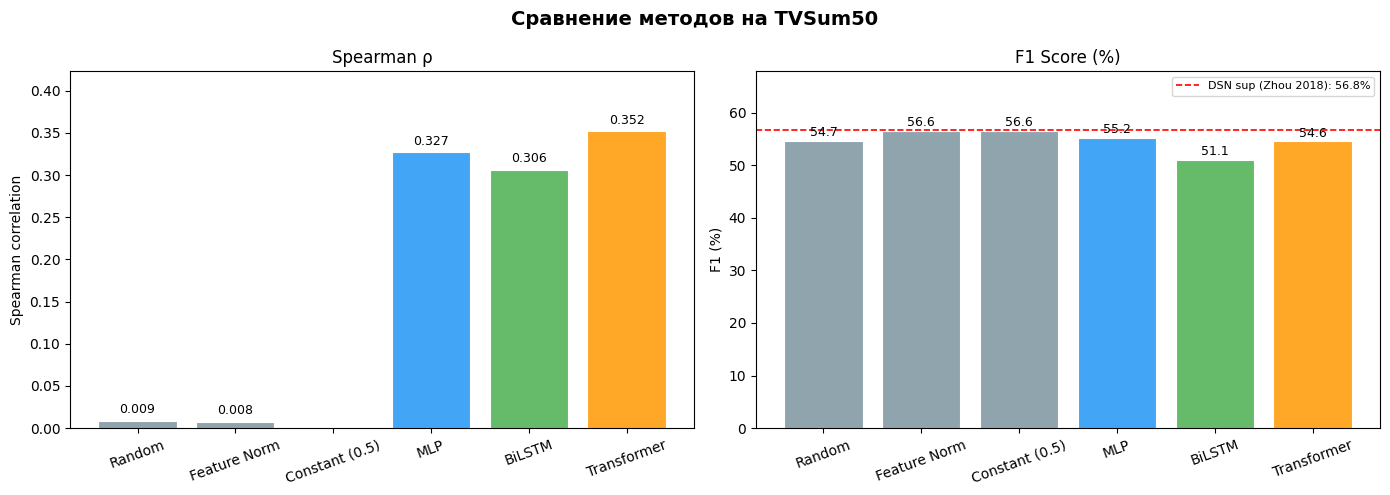

Финальное обучение BiLSTM: 100%|██████████| 50/50 [14:12<00:00, 17.05s/it]


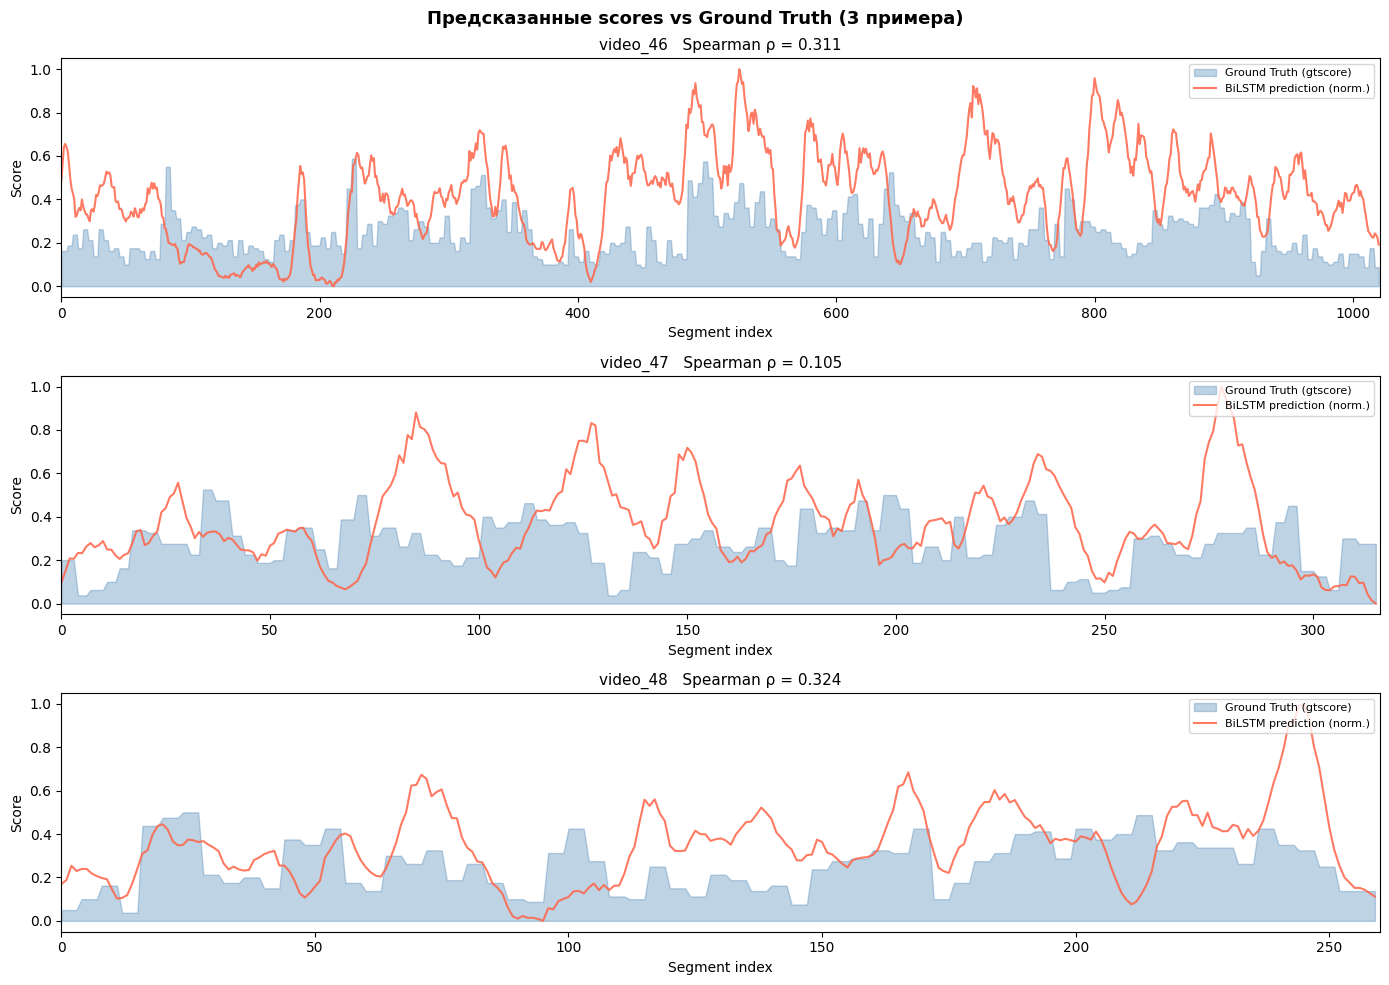

Графики сохранены: results_comparison.png, predictions_vs_gt.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Сравнение методов на TVSum50', fontsize=14, fontweight='bold')

methods = list(all_methods.keys())
colors  = ['#90a4ae'] * 3 + ['#42a5f5', '#66bb6a', '#ffa726']
colors  = colors[:len(methods)]

# Spearman
spear_vals = [all_methods[m]['spearman'] for m in methods]
bars = axes[0].bar(methods, spear_vals, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Spearman ρ')
axes[0].set_ylabel('Spearman correlation')
axes[0].set_ylim(0, max(spear_vals) * 1.2)
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, spear_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# F1
f1_vals = [all_methods[m]['f1'] for m in methods]
bars2 = axes[1].bar(methods, f1_vals, color=colors, edgecolor='white', linewidth=0.8)
axes[1].set_title('F1 Score (%)')
axes[1].set_ylabel('F1 (%)')
axes[1].set_ylim(0, max(f1_vals) * 1.2)
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(56.8, color='red', linestyle='--', linewidth=1.2, label='DSN sup (Zhou 2018): 56.8%')
axes[1].legend(fontsize=8)
for bar, v in zip(bars2, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('images/results_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Предсказанные scores vs Ground Truth (3 примера)', fontsize=13, fontweight='bold')

# Показываем предсказания лучшей нейросетевой модели (BiLSTM)
# Показываем предсказания лучшей нейросетевой модели (BiLSTM)
best_model = BiLSTM(feat_dim=1024, hidden=256, num_layers=2).to(DEVICE)
best_model.lstm = best_model.lstm.cpu()  # ← добавь эту строку
best_opt = optim.Adam(best_model.parameters(), lr=1e-4, weight_decay=1e-5)
for _ in tqdm(range(50), desc='Финальное обучение BiLSTM'):
    train_one_epoch(best_model, video_keys[:40], best_opt)

example_keys = video_keys[40:43]  # 3 тестовых видео
for ax, key in zip(axes, example_keys):
    d = dataset[key]
    feats = torch.tensor(d['features'], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred = best_model(feats).squeeze(0).cpu().numpy()

    # Нормализуем для сравнения
    pred_norm = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)
    gt        = d['gtscore']
    t         = np.arange(len(gt))

    ax.fill_between(t, gt, alpha=0.35, color='steelblue', label='Ground Truth (gtscore)')
    ax.plot(pred_norm, color='tomato', linewidth=1.5, label='BiLSTM prediction (norm.)', alpha=0.85)

    corr = evaluate_spearman(pred, gt)
    ax.set_title(f'{key}   Spearman ρ = {corr:.3f}', fontsize=11)
    ax.set_xlabel('Segment index'); ax.set_ylabel('Score')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(0, len(gt))

plt.tight_layout()
plt.savefig('images/predictions_vs_gt.png', dpi=130, bbox_inches='tight')
plt.show()
print("Графики сохранены: images/results_comparison.png, images/predictions_vs_gt.png")

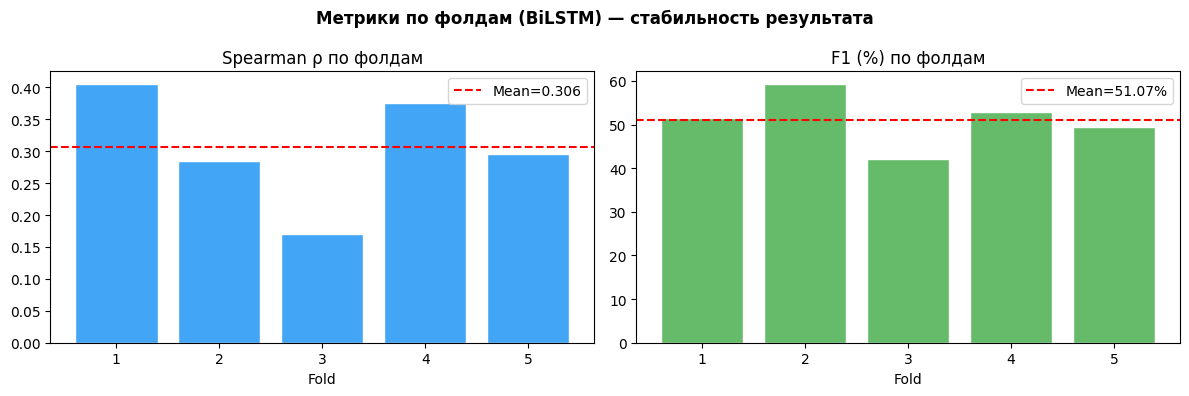

BiLSTM Spearman: 0.3064 ± 0.0822
BiLSTM F1:       51.07% ± 5.49%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Метрики по фолдам (BiLSTM) — стабильность результата', fontsize=12, fontweight='bold')

folds_spear = [h['spearman'] for h in hist_lstm]
folds_f1    = [h['f1'] for h in hist_lstm]

axes[0].bar(range(1, 6), folds_spear, color='#42a5f5', edgecolor='white')
axes[0].axhline(np.mean(folds_spear), color='red', linestyle='--', label=f'Mean={np.mean(folds_spear):.3f}')
axes[0].set_title('Spearman ρ по фолдам'); axes[0].set_xlabel('Fold'); axes[0].legend()

axes[1].bar(range(1, 6), folds_f1, color='#66bb6a', edgecolor='white')
axes[1].axhline(np.mean(folds_f1), color='red', linestyle='--', label=f'Mean={np.mean(folds_f1):.2f}%')
axes[1].set_title('F1 (%) по фолдам'); axes[1].set_xlabel('Fold'); axes[1].legend()

plt.tight_layout()
plt.savefig('images/fold_variance.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"BiLSTM Spearman: {np.mean(folds_spear):.4f} ± {np.std(folds_spear):.4f}")
print(f"BiLSTM F1:       {np.mean(folds_f1):.2f}% ± {np.std(folds_f1):.2f}%")

## 9. Сравнение подходов

Сравнение идёт по 3 осям:
- **Качество**: Spearman ρ и F1@15%.
- **Скорость инференса**: среднее время `sec/video`.
- **Ресурсы**: число параметров и тип вычислительной сложности.

Ниже — лёгкий бенчмарк инференса на CPU (без обучения), чтобы оценить применимость для массовой обработки.


### Как читать результаты и что нужно доработать на 2-м этапе

1. **Почему у Transformer выше Spearman, но F1 не лучший**:
   - Spearman проверяет порядок score,
   - а F1 зависит от того, как эти score превращаются в итоговое summary через сегменты и knapsack.

2. **Почему не делаем жёсткий вывод о победителе по F1**:
   - данных мало (50 видео),
   - разметка субъективная,
   - разброс по фолдам заметный,
   - разница в 1-2 п.п. может оказаться статистическим шумом.

3. **Что берём дальше**:
   - основной кандидат для доработки: **Transformer** (лучший Spearman),
   - сравнение ведём со всеми baseline и моделями,
   - улучшение считаем значимым только если прирост повторяется на нескольких фолдах.


## 10. План этапа 2 (шаги -> артефакты -> результат)

| Шаг | Что делаем | Что получаем | Какой результат ждём |
|---|---|---|---|
| 1 | Усиливаем проверку данных и фиксируем сплиты | `data_validation_report` + файлы сплитов | 0 критичных ошибок в данных |
| 2 | Тюним baseline и обучение моделей | Таблица абляций и лучший конфиг | Повторяемый прирост F1 на нескольких фолдах |
| 3 | Тюним post-processing (пороги, merge интервалов, smoothing) | Отдельный блок с параметрами | +1..3 p.p. F1 на валидации |
| 4 | Делаем разбор ошибок по длинам/жанрам | Таблица ошибок + примеры видео | Понимание, где модель ошибается чаще всего |
| 5 | Готовим финальную оценку и демо | Финальная таблица метрик + демо | Готовность к финальной защите |

### Что уже сделано на Stage 1
- Есть полный рабочий пайплайн: загрузка -> EDA -> baselines -> модели -> 5-fold CV -> графики.
- Метрики и правила расчёта зафиксированы (Spearman + F1@15%).
- Добавлены проверки качества данных и оценка скорости инференса.

## 11. Что закрыто по чек-листу Stage 1

- Постановка задачи, требования и ограничения.
- Данные: источники, структура, объём, ограничения, базовая проверка качества.
- Разметка/таргет: явно описаны `gtscore` и `user_summary`.
- EDA и проверка качества данных.
- Признаки/представления и их ограничения.
- Подходы и baseline (сравнение по качеству/скорости/ресурсам без завышенных выводов по малой выборке).
- Метрики и правила расчёта (с обработкой `nan` у Spearman).
- План этапа 2 с шагами и ожидаемыми артефактами.
